# Robot Predictive Maintenance — Data Streaming and Visualization

**Group 4 — Namy, Davis, Carlos, Rangeetha**

A materials-handling robot failed and took 480 minutes of production with it. The failure was wear in a torque tube, and nobody saw it coming because there was no way to watch the robot's health while it ran.

This notebook builds the tool that would have seen it. It reads the electrical current each of the robot's joints draws, stores every reading in a cloud database, shows them on a live chart, and looks for readings that suggest something is going wrong.

**The data.** One Kawasaki robot, recorded on 17–18 October 2022. 39,672 readings taken about every 2 seconds across 22.5 hours. Each reading is the current in amps for eight joints. The export format has fourteen axis columns but this robot only has eight, so columns 9 to 14 are empty in every row.

**How it fits together.**

```
CSV file  ->  StreamingSimulator  ->  insert_reading()  ->  Neon database
                                   -> dashboard.update()  ->  live chart
                                                    Neon  ->  fetch_all()  ->  analysis
```

**Who built what.** Rangeetha set up the Neon database and the functions that read and write it. Davis wrote the simulator that replays the CSV as if a robot controller were sending it. Carlos built the dashboard and the standalone web app. Namy wrote the analysis and anomaly detection, and merged everyone's work together.

The instructor's brief is in `instructor_material.ipynb`.

## Setup

Run this section first — every later cell depends on it.

**What this cell does:** loads the tools we need and sets up where things live.

- `pandas` handles tables of data. A table in pandas is called a **DataFrame** — think of a spreadsheet you can work with in code.
- `matplotlib` draws charts.
- `clear_output` and `display` let us replace a chart in place, which is how the live dashboard appears to animate.

`CSV_PATH` is where the raw data file sits. `AXIS_COLUMNS` is the list of the eight joints we care about, so we never have to type them out again.

`CANONICAL_MAX_ID` marks where the real data ends. Our one-time data load filled rows 1 to 39,672, so any row numbered higher than that was added later by a demo and can be safely deleted.

In [93]:
# CELL 1: imports, paths, constants
import sys
from pathlib import Path

from matplotlib import pyplot as plt
import pandas as pd
from IPython.display import clear_output, display
# from src.web_ui import web_ui_interface


REPO_ROOT = Path.cwd()
CSV_PATH = REPO_ROOT / 'data'/ "RMBR4-2_export_test.csv"
AXIS_COLUMNS = [f"axis_{i}" for i in range(1, 9)]

# ids 1..39,672 came from the one-time bulk migration. Anything above this
# was added by a live demo and is removed after Step 2, so repeated demo runs
# never accumulate in the table.
CANONICAL_MAX_ID = 39_672


## Step 1 — Connect to the database and load the data

Before we can stream anything we need two things: somewhere to put the readings, and the readings themselves.

**What this cell does:** connects to our Neon database and pulls every stored reading into a DataFrame.

Neon is a PostgreSQL database that runs in the cloud, so all four of us read and write the same table from our own laptops.

The four functions come from `src/data_collection/data_collection_agent.py`:

| function | what it does |
|---|---|
| `get_connection()` | opens a connection to the database |
| `insert_reading()` | saves one reading |
| `fetch_all()` | reads every reading back as a DataFrame |
| `fetch_since()` | reads only readings newer than a given time |

We should see **39,672 rows**. Each row has an `id` (a row number the database assigns), the eight currents in amps, and `reading_time` — when the controller took that measurement.

In [94]:
# CELL 2: connect to Neon and confirm the table
from src.data_collection.data_collection_agent import fetch_all, fetch_since, get_connection, insert_reading
readings = fetch_all()
print(f"{len(readings):,} rows in robot_readings")
readings.head(20)


39,672 rows in robot_readings


    id    trait  axis_1  axis_2  axis_3  axis_4  axis_5  axis_6  axis_7  \
0    1  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
1    2  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2    3  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3    4  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
4    5  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
5    6  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
6    7  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
7    8  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
8    9  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
9   10  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
10  11  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
11  12  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
12  13  current     0.0  

**What this cell does:** reads the same data straight from the CSV file, so we have a copy in memory as well as in the database.

Two things happen. `usecols` keeps only the eight axes that hold data, ignoring the six empty ones. Then we rename the columns so the CSV's names match the database's names — `Axis #1` becomes `axis_1`, `Time` becomes `reading_time`.

That rename is small but it saves real trouble. Because both sources now use identical names, any analysis we write works on either one without changing a single line.

In [95]:
# CELL 3: load the CSV into a DataFrame
df_raw = pd.read_csv(
    CSV_PATH,
    usecols=["Trait", *[f"Axis #{i}" for i in range(1, 9)], "Time"],
    parse_dates=["Time"]
)
df_raw = df_raw.rename(
    columns={
         "Trait": "trait",
        "Time": "reading_time",
        **{f"Axis #{i}": f"axis_{i}" for i in range(1, 9)},
    }
)
print(f"{len(df_raw):,} rows loaded from CSV")
df_raw.head()

39,672 rows loaded from CSV


     trait  axis_1  axis_2  axis_3  axis_4  axis_5  axis_6  axis_7  axis_8  \
0  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
1  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
4  current     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

                      reading_time  
0 2022-10-17 12:18:23.660000+00:00  
1 2022-10-17 12:18:25.472000+00:00  
2 2022-10-17 12:18:27.348000+00:00  
3 2022-10-17 12:18:29.222000+00:00  
4 2022-10-17 12:18:31.117000+00:00  

### Team Talking Point — Step 1

**The table we first created was shaped by the file, not by the data.**

Our first load handed the CSV straight to pandas' `to_sql()`, which builds a table by copying
whatever the file looks like. That gave us all fourteen axis columns — including the six that are
empty in every one of the 39,672 rows — and it stored the timestamp as plain text rather than as a
date.

The text timestamp was the real problem. A database can group text alphabetically but it cannot
group it by hour, so the hourly analysis in Step 3 was impossible until we fixed it.

We rebuilt the table with eight axis columns and a proper timestamp type. Because all four of us
share one database, we did not drop the old table and start again — anyone running a query during
the reload would have hit a table that did not exist. Instead we built the new table alongside the
old one, loaded it, checked the row count and time span matched exactly, and only then renamed the
two tables. That swap takes milliseconds. The old table is still there as `robot_readings_old`.

## Step 2 — Stream the readings live

The robot controller sends one reading every couple of seconds. We replay the CSV at that same pace so the rest of the system behaves exactly as it would against a real robot.

**What this cell does:** creates the simulator that stands in for the robot controller.

`nextDataPoint()` hands back one reading at a time and remembers where it got to, the way a controller would send one message after another.

Look at the keys it returns: `trait`, `axis_1` … `axis_8`, `reading_time`. Those are exactly the column names in our database, which means a reading can be saved with no conversion step in between. Getting the two sides to agree on names was the main thing we had to fix when we merged our work.

In [96]:
# CELL 4: StreamingSimulator: one reading via nextDataPoint()
from src.data_collection.streaming_simulator import StreamingSimulator

ss = StreamingSimulator(CSV_PATH) 
first_record = ss.nextDataPoint()
first_record


{'trait': 'current',
 'axis_1': np.float64(0.0),
 'axis_2': np.float64(0.0),
 'axis_3': np.float64(0.0),
 'axis_4': np.float64(0.0),
 'axis_5': np.float64(0.0),
 'axis_6': np.float64(0.0),
 'axis_7': np.float64(0.0),
 'axis_8': np.float64(0.0),
 'reading_time': Timestamp('2022-10-17 12:18:23.660000+0000', tz='UTC')}

**What this cell does:** builds the live dashboard.

It keeps the most recent 30 readings and redraws the chart each time a new one arrives. Older readings drop off the end, so the chart always shows roughly the last minute — which is what a live dashboard is for. The full history stays in the database.

The chart is a **stacked area chart**: each joint's current is piled on top of the one below, so the height of the whole stack is the robot's total draw and each coloured band is one joint's share. This matches the dashboard design in the use case.

Each joint keeps the same colour throughout, so Axis 3 is always the same green. We checked the eight colours stay distinguishable for colourblind readers, and we print the exact amps under the chart as well — colour should never be the only way to read a chart.

Running this cell only sets the dashboard up. Nothing is drawn until readings arrive.

In [ ]:
# Validated 8-hue categorical palette, assigned to axes in fixed order.
# Never cycle or reorder these -- axis_3 must stay the same color when the
# chart is filtered or rescaled, or the reader has to re-learn it every tick.
AXIS_COLORS = {
    "axis_1": "#2a78d6",  # blue
    "axis_2": "#eb6834",  # orange
    "axis_3": "#1baf7a",  # aqua
    "axis_4": "#eda100",  # yellow
    "axis_5": "#e87ba4",  # magenta
    "axis_6": "#008300",  # green
    "axis_7": "#4a3aa7",  # violet
    "axis_8": "#e34948",  # red
}

SURFACE = "#fcfcfb"
INK = "#0b0b0b"
INK_MUTED = "#52514e"


class LiveDashboard:
    """Rolling per-axis current chart that redraws as readings arrive."""

    def __init__(self, window=30):
        self.window = window
        self.records = []

    def update(self, record):
        self.records.append(record)
        self.records = self.records[-self.window:]
        self.draw()

    def draw(self):
        df = pd.DataFrame(self.records)

        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(11, 4.5), facecolor=SURFACE)
        ax.set_facecolor(SURFACE)

        # Stacked: the top edge is total draw, each band is one joint's share.
        # edgecolor=SURFACE puts a thin gap between bands so adjacent hues do not
        # blur into each other. Same form as the standalone Dash dashboard.
        ax.stackplot(
            df["reading_time"],
            *[df[column] for column in AXIS_COLUMNS],
            colors=[AXIS_COLORS[column] for column in AXIS_COLUMNS],
            labels=[column.replace("axis_", "Axis ") for column in AXIS_COLUMNS],
            edgecolor=SURFACE,
            linewidth=1,
        )

        total = df[AXIS_COLUMNS].sum(axis=1)
        ax.set_title(
            f"Realtime current (Amps, stacked) — total {total.iloc[-1]:.1f}A",
            color=INK, fontsize=13, fontweight="600", loc="left", pad=34,
        )
        ax.set_ylabel("current (A)", color=INK_MUTED, fontsize=10)
        ax.tick_params(colors=INK_MUTED, labelsize=9)

        # Recessive grid and axes: the data should be the darkest thing here.
        ax.grid(axis="y", color="#d8d7d2", linewidth=0.8, alpha=0.7)
        ax.set_axisbelow(True)
        for side in ("top", "right", "left"):
            ax.spines[side].set_visible(False)
        ax.spines["bottom"].set_color("#d8d7d2")

        # Legend along the top, matching the reference PM dashboard layout.
        ax.legend(
            loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=8,
            frameon=False, fontsize=9, labelcolor=INK_MUTED,
        )

        fig.autofmt_xdate()
        fig.tight_layout()
        display(fig)
        plt.close(fig)

        # Relief for the low-contrast hues: current values in text, not color alone.
        latest = df.iloc[-1]
        print("  ".join(f"{c.replace('axis_', 'A')}:{latest[c]:5.1f}" for c in AXIS_COLUMNS))


# 60 keeps a whole duty cycle on screen: idle, working, idle again.
dashboard = LiveDashboard(window=60)
print("dashboard ready")


**What this cell does:** the streaming demo itself.

For each reading we save it to the database and redraw the chart, one reading every 2 seconds as the brief asks. Thirty readings takes about a minute.

`on_tick` is a **callback** — a function we hand to the simulator so it can call us back once per reading. It keeps the simulator ignorant of databases and charts; it just announces each reading and we decide what to do with it.

**Why we start at reading 11,604.** The recording opens at 12:18 while the robot is sitting still, so streaming from the beginning drew a flat line at zero. Reading 11,604 starts a stretch where the robot is working and where nothing is missing from the recording. Step 3 still analyses all 39,672 readings, idle ones included.

In [ ]:
# CELL 6: stream a slice: insert into Neon + update the chart each tick


def on_tick(record):
    """One tick: persist the reading, then redraw the chart"""
    insert_reading(record)
    dashboard.update(record)


ss = StreamingSimulator(CSV_PATH)   # interval=2.0 default, per the instruction

# Stream from the very first reading so the chart shows one complete duty cycle:
# readings 0-29 idle, 30-44 working (peaking at 71A), then idle again from 45.
# 60 readings covers the whole cycle. Step 3 analyses all 39,672 readings.
demo_records = ss.run(n_steps=60, on_tick=on_tick)
print(f"streamed {len(demo_records)} readings at {ss.interval}s intervals")



**What this cell does:** deletes the rows the demo just added, putting the table back to its 39,672 real readings.

The demo writes into the same table we analyse, so without this every run would leave duplicates behind and slowly distort our results.

We delete everything numbered above `CANONICAL_MAX_ID`. Our first attempt compared against whatever the highest row number was just before the demo started, which quietly broke when we ran the demo twice without cleaning up in between — the second run's baseline already included the first run's leftovers. 270 stray rows built up and shifted our anomaly counts before we caught it. Pinning a fixed number fixes it no matter how often the demo runs.

In [99]:
with get_connection() as connection:
    deleted = connection.execute(
        "DELETE FROM robot_readings WHERE id > %s", (CANONICAL_MAX_ID,)
    ).rowcount
    connection.commit()

print(f"removed {deleted} demo rows; table back to its canonical {len(fetch_all()):,}")


removed 30 demo rows; table back to its canonical 39,672


### Team Talking Point — Step 2

**Our first live demo drew a flat line at zero, and the chart was right.**

Rather than assume the dashboard was broken, we checked it against our own data profile and found
the robot genuinely is not moving for the first 30 readings — 64% of the whole dataset is idle. The
recording simply opens during a quiet period.

Our second attempt found a subtler problem. The window we picked straddled a 33-second gap in the
recording, and a stacked area chart joins the points either side of a gap with a straight line. The
chart showed a smooth ramp during a period when there was no data at all. On a real maintenance
dashboard that is worse than a blank space, because it invents a trend an operator might act on. We
moved to a window with no gaps and said so in the code comment.

Both problems looked like chart bugs and neither was. Knowing what the data actually contains is
what let us tell the difference.

## Step 3 — Find patterns in the data

Before deciding what counts as abnormal, we need to know what normal looks like.

**What this cell does:** profiles the CSV snapshot used by both Steps 3 and 4.

We call a sample **idle** when all eight measured currents equal zero. This is an operational proxy, not proof of the robot's physical state. We report idle and active sample counts, mean current during robot-active samples, and the percentage of recorded samples that are idle in each hour. These are sample percentages, not exact time-weighted durations. Missing timestamps and measurements must be resolved before analysis.

In [ ]:
# CELL 7: data profile: idle vs active, per-axis load, hourly idle %
# Use the CSV snapshot so demo database inserts cannot change the analysis.
df = df_raw.sort_values("reading_time").reset_index(drop=True).copy()
if df[AXIS_COLUMNS].isna().any().any() or df["reading_time"].isna().any():
    raise ValueError("Missing measurements or timestamps: validate the input first.")
if df["reading_time"].duplicated().any():
    raise ValueError("Duplicate timestamps: resolve them before analysis.")

# A reading is "idle" only when every axis reads exactly zero.
df["idle"] = (df[AXIS_COLUMNS] == 0).all(axis=1)

print(f"total readings : {len(df):,}")
print(f"idle           : {df['idle'].sum():,}  ({df['idle'].mean():.1%})")
print(f"active         : {(~df['idle']).sum():,}  ({(~df['idle']).mean():.1%})")

print("\nmean current per axis when active:")
print(df.loc[~df["idle"], AXIS_COLUMNS].mean().round(2).to_string())

print("\nidle sample % per hour:")
df["hour"] = df["reading_time"].dt.floor("h")
hourly = df.groupby("hour").agg(readings=("idle", "size"), idle_pct=("idle", "mean"))
hourly["idle_pct"] = (hourly["idle_pct"] * 100).round(1)
print(hourly.to_string())

# Explicitly distinguish missing observations from recorded zero current.
gaps = df["reading_time"].diff().dt.total_seconds()
print("\nRecording gaps longer than 10 seconds:")
print(df.loc[gaps > 10, ["reading_time"]].assign(gap_seconds=gaps[gaps > 10]).to_string(index=False))
runs = df["idle"].ne(df["idle"].shift()).cumsum()
idle_runs = df.groupby(runs).agg(idle=("idle", "first"), start=("reading_time", "min"), end=("reading_time", "max"))
idle_runs["duration"] = idle_runs["end"] - idle_runs["start"]
print("\nLongest consecutive all-zero run (observed endpoints):")
print(idle_runs.loc[idle_runs["idle"]].nlargest(1, "duration").to_string(index=False))

total readings : 39,672
idle           : 25,487  (64.2%)
active         : 14,185  (35.8%)

mean current per axis when active:
axis_1     2.03
axis_2    10.11
axis_3     7.58
axis_4     1.73
axis_5     2.67
axis_6     1.68
axis_7     2.43
axis_8     0.29

idle sample % per hour:
                           readings  idle_pct
hour                                         
2022-10-17 12:00:00+00:00      1040      73.3
2022-10-17 13:00:00+00:00      1623      61.4
2022-10-17 14:00:00+00:00      1784      44.4
2022-10-17 15:00:00+00:00      1756      72.1
2022-10-17 16:00:00+00:00      1798      99.8
2022-10-17 17:00:00+00:00      1778      82.1
2022-10-17 18:00:00+00:00      1782      51.4
2022-10-17 19:00:00+00:00      1782      49.7
2022-10-17 20:00:00+00:00      1765      43.3
2022-10-17 21:00:00+00:00      1788      59.2
2022-10-17 22:00:00+00:00      1785      58.3
2022-10-17 23:00:00+00:00      1782      45.7
2022-10-18 00:00:00+00:00      1791      60.1
2022-10-18 01:00:00+00:00      

**What this cell does:** the whole shift on one timeline — all 39,672 readings, 22.5 hours,
rather than the two-minute live window from Step 2.

The shaded band is the **highest** total current in each minute; the line is the **average** for
that minute. Together they show how hard the robot is pushed at its worst and what it typically
draws. The grey blocks are stoppages, labelled with how long each lasted.

**Why the highest and not just the average.** Our first version averaged each minute and the chart
topped out at 40A, when the robot actually reached 88A. Averaging hides the spikes inside a minute,
and the spikes are the part that stresses a joint.

**Why one line instead of eight.** Drawing all eight joints unaggregated puts about 30 readings on
every pixel and the colours blend into grey. The per-joint breakdown is in the live chart above and
in the summary chart at the end; this one answers a different question — how loaded was the robot
across the whole shift.

In [ ]:
# CELL 7b: the entire dataset on one timeline
full = fetch_all()
total = full.set_index("reading_time")[AXIS_COLUMNS].sum(axis=1)

# Total current first, THEN bucket by minute. Taking the max keeps the real peaks:
# averaging the readings instead shows 40A where the robot actually drew 88A.
peak_per_minute = total.resample("1min").max().fillna(0.0)
mean_per_minute = total.resample("1min").mean().fillna(0.0)

# Find stoppages: runs of 20 or more consecutive minutes with no movement at all.
is_idle = peak_per_minute == 0
run_id = (is_idle != is_idle.shift()).cumsum()
stoppages = [
    (run.index[0], run.index[-1], len(run))
    for _, run in is_idle.groupby(run_id)
    if run.iloc[0] and len(run) >= 20
]

fig, ax = plt.subplots(figsize=(13, 4.4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

for start, end, minutes in stoppages:
    ax.axvspan(start, end, color="#d8d7d2", alpha=0.55, linewidth=0, zorder=0)
    label = f"stopped\n{minutes // 60}h {minutes % 60}m" if minutes >= 60 else f"stopped\n{minutes}m"
    ax.annotate(label, xy=(start + (end - start) / 2, peak_per_minute.max() * 0.82),
                ha="center", va="center", fontsize=9, color=INK_MUTED, zorder=5)

ax.fill_between(peak_per_minute.index, peak_per_minute.values,
                color=AXIS_COLORS["axis_2"], alpha=0.22, linewidth=0, zorder=1)
ax.plot(peak_per_minute.index, peak_per_minute.values,
        color=AXIS_COLORS["axis_2"], linewidth=0.7, zorder=2, label="peak in each minute")
ax.plot(mean_per_minute.index, mean_per_minute.values,
        color=AXIS_COLORS["axis_7"], linewidth=1.3, zorder=3, label="average in each minute")

ax.set_title(f"Total current across all joints — all {len(full):,} readings",
             color=INK, fontsize=13, fontweight="600", loc="left", pad=28)
ax.set_ylabel("current (A)", color=INK_MUTED, fontsize=10)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color="#d8d7d2", linewidth=0.8, alpha=0.6)
ax.set_axisbelow(True)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#d8d7d2")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.005), ncol=2,
          frameon=False, fontsize=9, labelcolor=INK_MUTED)
ax.margins(x=0)
ax.set_ylim(0, peak_per_minute.max() * 1.05)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

print(f"peak total current over the shift: {total.max():.1f}A")
print(f"{len(stoppages)} stoppages of 20 minutes or more:")
for start, end, minutes in stoppages:
    print(f"  {start:%d %b %H:%M} to {end:%d %b %H:%M}  ({minutes} min)")


#### Step 3 findings

- **25,487 of 39,672 samples (64.24%) have all eight currents at zero.** The remaining 14,185 samples are robot-active under our definition.
- During robot-active samples, Axis 2 averages **10.1057 A** and Axis 3 **7.5802 A**. Together they represent about 62% of summed measured current, not a measured share of energy or mechanical work.
- The 03:00, 04:00 and 05:00 UTC hours on 18 October are mostly idle: **95.4%, 100.0% and 99.6%** of recorded samples. They do not form one uninterrupted three-hour stop. The longest consecutive all-zero run spans **03:09:36–05:38:56 UTC**, approximately **2 h 29 min** between observed endpoints.
- There are **six gaps longer than 10 seconds**: 402.538 s, 332.610 s and four approximately 33 s gaps. Missing observations do not establish whether the robot was idle.
- Of 1,347 one-minute buckets, **493 contain only observed zero readings**, and **9 have no observations**. These bucket counts differ from the raw-sample idle percentage.

### Team Talking Point — Step 3

**Choose the average that answers the question.**

Axis 2 averages about 3.6 A across all samples and 10.1 A during robot-active samples. Both calculations are valid: the first describes the observed recording overall, while the second describes current conditional on activity. Neither establishes whether the robot was switched off. The overview includes all samples; the operating-current statistics and anomaly detector use robot-active samples.

## Step 4 — Turn the patterns into maintenance alerts

A dashboard that only draws lines still needs a person watching it. This step looks for the readings worth raising an alert about.

**What this cell does:** looks for unusual readings, and for any sign the robot is wearing out.

**How a reading gets flagged.** For each joint we take the **30 readings immediately before** the
one being tested, and ask whether the new reading fits that pattern.

Using the largest deviation we found on axis 2 as a worked example:

| Step | Value |
|---|---|
| The 30 readings before it | sum to 306.70 A |
| **Baseline** = sum ÷ 30 | **10.22 A** — what this joint has been drawing lately |
| **Standard deviation (sd)** | **7.33 A** — how much those 30 typically wobble around the baseline |
| The reading being tested | 51.24 A |
| **Deviation** = reading − baseline | **41.02 A** |
| **z-score** = deviation ÷ sd | **5.60** |

A z-score of 5.60 means the reading sits 5.6 "typical wobbles" above where this joint has been
running. We flag anything past **3**. Both numbers matter: the z-score says *unusual*, the
deviation in amps says *how much*.

**Three rules that shape the result.**

1. **Only readings where the robot is moving are scored.** 64% of the data is idle zeros. A window
   full of zeros has almost no wobble, so the instant the robot moves the score explodes.
2. **The baseline never includes the reading being tested, and never spans a stoppage.** More than
   60 seconds between readings starts a new session, and the first 30 readings of a session are not
   scored at all — there is no history yet to compare them against.
3. **The settings are a choice.** A shorter window or lower threshold flags far more; the
   sensitivity table in the next cell shows the range.

**Reading the results carefully:** the number of flags per joint is not severity. A z-score asks
whether a reading is unusual *for that joint*, so a 4A blip on axis 8 (which normally draws 0.3A)
scores higher than the same 4A on axis 2 (which averages 10A). Ranking maintenance work by flag
count would send an engineer to the wrong joint.

**Why 30 readings and not the whole dataset?** A fixed baseline computed from all 14,185 active readings would flag only readings above about 34.7A, and would miss 124 of the spikes we catch — a 31A jump while the robot had been idling at 8.4A is a real event that a whole-dataset average shrugs at. `METHODOLOGY.md` works through the comparison.

In [ ]:
# CELL 8: historical baseline, shared activity definition, session resets
CRITICAL = "#d03b3b"

# Where a joint has been almost steady, the spread of the preceding readings can be
# about 0.01A, and dividing by it turns an ordinary 1A change into a score above 100.
# Floor the divisor at the level below which a difference is sensor noise rather than
# a real change. The unfloored spread is kept for the constant-baseline test below.
NOISE_FLOOR_AMPS = 0.1


def detect_anomalies(df, axis_col, window=30, threshold=3.0,
                     reset_gap_seconds=60, min_deviation_amps=0.0):
    """Return statistical flags; warm-up and constant baselines are explicit."""
    if window < 2 or threshold <= 0 or reset_gap_seconds <= 0 or min_deviation_amps < 0:
        raise ValueError("Invalid detector settings")
    active = df.loc[df[AXIS_COLUMNS].ne(0).any(axis=1)].sort_values("reading_time").copy()
    session = active["reading_time"].diff().dt.total_seconds().gt(reset_gap_seconds).cumsum()
    groups = active[axis_col].groupby(session)
    mean = groups.transform(lambda s: s.shift(1).rolling(window, min_periods=window).mean())
    std = groups.transform(lambda s: s.shift(1).rolling(window, min_periods=window).std())
    delta = active[axis_col] - mean
    ready = mean.notna() & std.notna()
    variable = ready & std.gt(0)
    divisor = std.clip(lower=NOISE_FLOOR_AMPS)
    active["z_score"] = delta / divisor.where(variable)
    meaningful_change = delta.abs().gt(min_deviation_amps)
    constant_change = ready & std.eq(0) & meaningful_change
    unusual = variable & active["z_score"].abs().gt(threshold) & meaningful_change
    active["reason"] = "z_score"
    active.loc[constant_change, "reason"] = "constant_baseline_change"
    active["deviation_amps"] = delta
    active["baseline_amps"] = mean
    active["axis"] = axis_col
    active["value"] = active[axis_col]
    return active.loc[unusual | constant_change,
                      ["reading_time", "axis", "value", "baseline_amps", "z_score", "deviation_amps", "reason"]]


alerts = pd.concat([detect_anomalies(df, column) for column in AXIS_COLUMNS], ignore_index=True)
alerts = alerts.sort_values("reading_time", ignore_index=True)
print(f"{len(alerts):,} axis-level flags across {alerts['reading_time'].nunique():,} timestamps")
print("\nFlags by axis and reason:")
print(pd.crosstab(alerts["axis"], alerts["reason"]).to_string())
print("\nLargest absolute changes from baseline (not a cross-axis risk ranking):")
print(alerts.loc[alerts["deviation_amps"].abs().nlargest(5).index].round(2).to_string(index=False))

# Descriptive hourly diagnostics, not a validated degradation model.
active_only = df.loc[~df["idle"]]
hourly_mean = active_only.groupby("hour")[AXIS_COLUMNS].mean()
active_counts = active_only.groupby("hour").size()
print("\nActive sample counts per observed active hour:")
print(active_counts.to_string())
endpoint_summary = pd.DataFrame({"first_hour_A": hourly_mean.iloc[0],
                                 "last_hour_A": hourly_mean.iloc[-1]})
endpoint_summary["change_pct"] = (endpoint_summary["last_hour_A"] / endpoint_summary["first_hour_A"].replace(0, float("nan")) - 1) * 100
print("\nPer-axis endpoint comparison (partial hours; workload not controlled):")
print(endpoint_summary.round(2).to_string())
first, last = hourly_mean.sum(axis=1).iloc[[0, -1]]
print(f"\nAggregate endpoint change: {(last / first - 1):+.2%}")
print("This comparison neither establishes nor rules out degradation.")

fig, ax = plt.subplots(figsize=(11, 4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

axis_2_active = df.loc[~df["idle"]].copy()

# Break the line wherever the robot stopped for more than a minute. Without this
# matplotlib joins the points either side of a long stoppage with a straight
# line, which draws a trend across a period that has no readings at all.
stopped = axis_2_active["reading_time"].diff().dt.total_seconds() > 60
axis_2_active.loc[stopped, "axis_2"] = float("nan")

ax.plot(axis_2_active["reading_time"], axis_2_active["axis_2"],
        color=AXIS_COLORS["axis_2"], linewidth=0.7, alpha=0.6)

axis_2_alerts = alerts[alerts["axis"] == "axis_2"]
ax.scatter(axis_2_alerts["reading_time"], axis_2_alerts["value"],
           color=CRITICAL, s=22, zorder=3, label=f"statistical flag ({len(axis_2_alerts)})")

ax.set_title("Axis 2 current while active, with statistical flags",
             color=INK, fontsize=13, fontweight="600", loc="left", pad=34)
ax.set_ylabel("current (A)", color=INK_MUTED, fontsize=10)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color="#d8d7d2", linewidth=0.8, alpha=0.7)
ax.set_axisbelow(True)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#d8d7d2")
ax.legend(frameon=False, fontsize=9, labelcolor=INK_MUTED,
          loc="lower center", bbox_to_anchor=(0.5, 1.02))
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

### How reliable are these flags?

We checked the default detector against a separate NumPy calculation using the previous 30 active samples in each session. Both implementations produced the same flagged axis/timestamp pairs. This verifies implementation agreement, **not fault-detection accuracy**.

The audit below reports scoring coverage and sensitivity to window/threshold choices. Different windows also change how many samples survive warm-up, so compare both counts and percentages. It does not choose the setting with the fewest flags: fewer flags alone do not establish better detection.

The CSV contains current and timestamps, with no fault labels or operating-task labels. Precision, recall and the false-alarm rate cannot be established from this file. Known healthy cycles and confirmed fault periods are needed for validation. Until then, treat the results as **candidate unusual readings for inspection**, not maintenance decisions. See [scikit-learn's precision definition](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html), which requires true labels as well as predictions.

In [ ]:
# CELL 8b: scoring coverage and sensitivity (not a fault-accuracy score)
active_audit = df.loc[~df["idle"]].sort_values("reading_time")
audit_sessions = active_audit["reading_time"].diff().dt.total_seconds().gt(60).cumsum()
position_in_session = active_audit.groupby(audit_sessions).cumcount()
scored_count = int(position_in_session.ge(30).sum())
flagged_timestamps = alerts["reading_time"].nunique()
print(f"Default settings score {scored_count:,} of {len(active_audit):,} robot-active timestamps.")
print(f"{len(active_audit) - scored_count:,} active timestamps are excluded by session warm-up.")
print(f"{flagged_timestamps:,} scored timestamps ({flagged_timestamps / scored_count:.1%}) have at least one axis flag.")

sensitivity_rows = []
for audit_window in [15, 30, 60]:
    eligible = int(position_in_session.ge(audit_window).sum())
    for audit_threshold in [2.5, 3.0, 4.0]:
        trial = pd.concat([detect_anomalies(df, column, window=audit_window, threshold=audit_threshold)
                           for column in AXIS_COLUMNS], ignore_index=True)
        timestamp_count = trial["reading_time"].nunique()
        sensitivity_rows.append({"window": audit_window, "threshold": audit_threshold,
                                 "scored_timestamps": eligible, "axis_flags": len(trial),
                                 "flagged_timestamps": timestamp_count,
                                 "flagged_scored_pct": round(100 * timestamp_count / eligible, 2) if eligible else float("nan")})
sensitivity = pd.DataFrame(sensitivity_rows)
print("\nSensitivity to detector settings (60-second session reset throughout):")
print(sensitivity.to_string(index=False))
print("\nAll-zero samples are excluded; this detector cannot detect a fault that appears solely as whole-robot inactivity.")
print("Fault precision/recall: unknown. The CSV has no confirmed fault labels.")


Default settings score 11,695 of 14,185 robot-active timestamps.
2,490 active timestamps are excluded by session warm-up.
2,620 scored timestamps (22.4%) have at least one axis flag.

Sensitivity to detector settings (60-second session reset throughout):
 window  threshold  scored_timestamps  axis_flags  flagged_timestamps  flagged_scored_pct
     15        2.5              12805        5797                4598               35.91
     15        3.0              12805        4541                3771               29.45
     15        4.0              12805        2904                2537               19.81
     30        2.5              11695        4020                3320               28.39
     30        3.0              11695        3050                2620               22.40
     30        4.0              11695        1779                1618               13.83
     60        2.5               9873        2841                2385               24.16
     60        3.0       

**Interpreting the results.** The output above is recalculated from the CSV; counts from the previous detector are no longer applicable. Multiple axes may flag at one timestamp. A flag means a reading differs from its historical operating baseline, not that a fault has been confirmed. Constant-baseline changes have an undefined z-score and are reported separately. The first 30 active samples of every session are unscored, and entirely idle rows are outside this detector's scope.

Because the current sample is excluded, the old self-included z-score ceiling does not apply. Absolute deviation in amps describes the size of a change, but comparing maintenance risk between joints requires rated limits, workload and fault evidence. Raw sums of deviations are not energy or a validated severity metric.

### Team Talking Point — Step 4

**Three things had to be true before the anomaly numbers meant anything, and each one changed the
answer.**

**The baseline must not contain the reading being judged.** Our first version compared each reading
against a 30-reading window that included itself. Nothing errored and the output looked plausible.
What gave it away was the list of most extreme readings: the top five scored 5.2935, 5.2934,
5.2929, 5.2914 and 5.2913. Real measurements do not agree to four decimal places. A single reading
inside a window of `n` can never score further than `(n-1)/√n` from a mean it is part of — 5.2947
for a 30-reading window — so past that point a mild excursion and a catastrophic one are
indistinguishable. We verified it by scoring an outlier of 10 and an outlier of 1,000,000 against
the same window; both returned exactly 5.294651.

**The baseline must not span a stoppage.** The robot stops for hours at a time. Without a session
reset, the first reading after a two-and-a-half-hour halt is compared against readings from before it, which
is not "recent behaviour" in any useful sense. We start a new session whenever more than 60 seconds
passes between readings, and we do not score the first 30 readings of a session at all — 2,490 of
14,185 active timestamps are excluded on that basis rather than scored against a half-formed
baseline.

**The settings are a choice, so we show what they cost.** At a 15-reading window and a 2.5
threshold the detector flags 35.9% of what it scores; at 60 and 4.0 it flags 11.2%. Publishing one
number without that range would imply a precision the method does not have.

We also state plainly what we cannot claim. The dataset has no confirmed fault labels, so we can
report how many readings we flag but not how many were real faults — precision and recall are
simply unknown. And one distortion survives: where a joint has been nearly steady, the spread of
the preceding readings can be about 0.01A, so an ordinary 1A change scores above 100. Our largest
score, 261, is a small denominator rather than a large deviation. That is why the severity ranking
uses amps above baseline rather than the z-score.

## Extra — A summary chart for the whole dataset

**What this cell does:** one chart covering all 39,672 readings instead of a live window,
showing how much current each joint uses overall.

We add up every reading for a joint and multiply by the time between readings, which gives
**amp-seconds** — current accumulated over time. It is not watts, because the controller does not
report voltage, so treat it as a way of comparing the joints against each other rather than a real
power figure.

A horizontal bar chart suits this because we are comparing eight named things by size, and
horizontal bars leave room for the labels. Each bar carries its own value and percentage, so
nothing depends on matching a colour to a legend. The bars keep the same colours the joints have
everywhere else in the notebook.

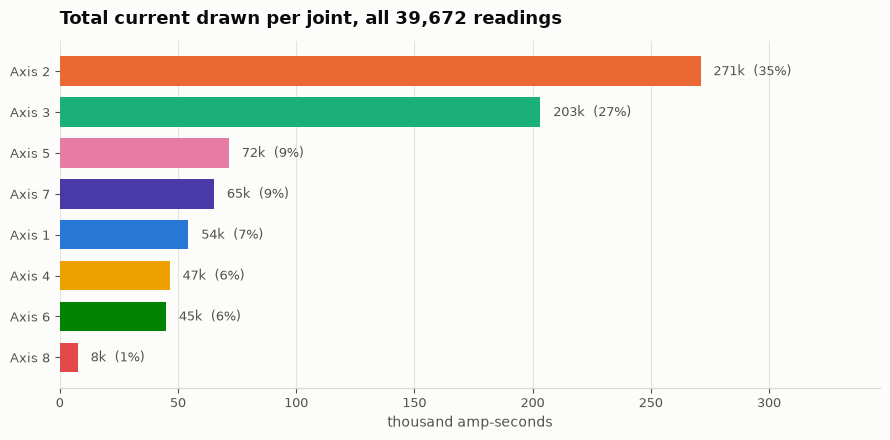

Axes 2 and 3 together account for 62% of all current drawn.
Axis 8 accounts for 1.0%.


In [102]:
# CELL 9: summary chart: energy consumption per axis, whole dataset
summary = fetch_all()
SAMPLE_SECONDS = summary["reading_time"].diff().dt.total_seconds().median()

# Energy proxy: current added up over time, in amp-seconds. We have no voltage
# reading, so this is not watts -- it compares the joints against each other.
energy = (summary[AXIS_COLUMNS].sum() * SAMPLE_SECONDS).sort_values()
share = energy / energy.sum()

fig, ax = plt.subplots(figsize=(9, 4.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

bars = ax.barh(
    [name.replace("axis_", "Axis ") for name in energy.index],
    energy.values / 1000,
    color=[AXIS_COLORS[name] for name in energy.index],
    height=0.72,
)

# Label every bar directly, so the numbers never depend on reading a colour.
for bar, value, pct in zip(bars, energy.values, share.values):
    ax.text(
        bar.get_width() + energy.max() / 1000 * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{value / 1000:,.0f}k  ({pct:.0%})",
        va="center", fontsize=9, color=INK_MUTED,
    )

ax.set_title(
    f"Total current drawn per joint, all {len(summary):,} readings",
    color=INK, fontsize=13, fontweight="600", loc="left", pad=12,
)
ax.set_xlabel("thousand amp-seconds", color=INK_MUTED, fontsize=10)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.set_xlim(0, energy.max() / 1000 * 1.28)
ax.grid(axis="x", color="#d8d7d2", linewidth=0.8, alpha=0.7)
ax.set_axisbelow(True)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#d8d7d2")
fig.tight_layout()
plt.show()

heavy = share[["axis_2", "axis_3"]].sum()
print(f"Axes 2 and 3 together account for {heavy:.0%} of all current drawn.")
print(f"Axis 8 accounts for {share['axis_8']:.1%}.")


## 🖥️ Appendix: standalone Dash dashboard

The notebook charts above are self-contained. `src/web_ui/` also holds a standalone Dash app built on the same database interface; run it with `python src/web_ui/web_ui_interface.py`.